# Module 7B — SI Demo: ROUGE Evaluation on XSum with BART-CNN

**Corpus:** XSum validation subset (50 examples) — BBC news, single-sentence abstractive references  
**Model:** `facebook/bart-large-cnn` — trained on CNN/DailyMail, paragraph-style summaries  
**Goal:** Build a ROUGE evaluation harness; observe how domain/style mismatch shapes scores; find a faithfulness failure ROUGE missed.

---
| Section | Topic | Time |
|---|---|---|
| 1 | Environment setup | 5 min |
| 2 | Load XSum demo subset | 5 min |
| 3 | Pipeline construction + one-document inference | 10 min |
| 4 | Generation hyperparameters | 15 min |
| 5 | ROUGE harness on a fixture | 10 min |
| 6 | Run pipeline + harness over XSum subset | 10 min |
| 7 | Aggregate ROUGE & per-summary distribution | 10 min |
| 8 | Faithfulness check | 10 min |
| 9 | Pivot to integration | 15 min |

## Section 1 — Environment Setup

In [ ]:
import sys
# Pin transformers to <5.0 — the "summarization" pipeline task was removed in v5.0.
# Use sys.executable so pip always installs into the kernel's own Python environment,
# not whichever python3 happens to be first on the system PATH.
!{sys.executable} -m pip install -q "transformers<5.0" datasets rouge-score pandas matplotlib
print("Restart the kernel now if transformers was just downgraded, then re-run from the top.")

In [1]:
from transformers import pipeline                          # HuggingFace inference wrapper
from datasets import load_dataset                          # HuggingFace dataset loader
from rouge_score import rouge_scorer as rs                 # Google's ROUGE implementation
import pandas as pd                                        # tabular analysis
import numpy as np                                         # numerical helpers
import matplotlib.pyplot as plt                            # score distribution plots
import warnings                                            # suppress noisy deprecation notices
warnings.filterwarnings("ignore")                          # keeps cell output clean during demo

/home/brandon/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


## Section 2 — Load XSum Demo Subset

In [2]:
# Load the first 50 examples from the XSum validation split
# Slice syntax [:50] avoids downloading the full 11k-example split
ds = load_dataset("xsum", split="validation[:50]")         # HuggingFace Hub; ~1s to stream

print(f"Dataset size   : {len(ds)} examples")             # confirm 50 rows loaded
print(f"Column names   : {ds.column_names}")              # 'document', 'summary', 'id'
print()
print("=== Article (first 300 chars) ===")
print(ds[0]["document"][:300])                            # BBC news article text
print()
print("=== XSum Reference Summary ===")
print(ds[0]["summary"])                                   # single highly-abstractive sentence

Dataset size   : 50 examples
Column names   : ['document', 'summary', 'id']

=== Article (first 300 chars) ===
The ex-Reading defender denied fraudulent trading charges relating to the Sodje Sports Foundation - a charity to raise money for Nigerian sport.
Mr Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42.
Appearing at the Old Bailey earlier, all four denied the offence.

=== XSum Reference Summary ===
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.


> **Observation prompt:** Notice the reference is ONE sentence — highly abstractive, not extractive. Keep this in mind when you see ROUGE scores later.

## Section 3 — Pipeline Construction + One-Document Inference

In [3]:
# Build the HuggingFace summarization pipeline
# facebook/bart-large-cnn was fine-tuned on CNN/DailyMail — paragraph-length summaries
# device=-1 forces CPU; change to device=0 to use a GPU if available
summarizer = pipeline(
    "summarization",                                      # task identifier
    model="facebook/bart-large-cnn",                      # ~1.6 GB; downloads on first run
    device=-1                                             # -1 = CPU
)

Device set to use cpu


In [4]:
article = ds[0]["document"]                               # grab the first article as a test

# Call the pipeline; returns a list of dicts — one dict per input document
result = summarizer(article, max_length=130, min_length=30, do_sample=False)

print("Return type      :", type(result))                 # <class 'list'>
print("Element type     :", type(result[0]))              # <class 'dict'>
print("Dict keys        :", result[0].keys())             # dict_keys(['summary_text'])
print()
print("=== Generated Summary (BART-CNN) ===")
print(result[0]["summary_text"])                          # access the text via index 0 + key
print()
print("=== Reference Summary (XSum style) ===")
print(ds[0]["summary"])                                   # XSum: one compressed sentence
print()
print("Notice: BART-CNN produces a multi-sentence paragraph; XSum expects one sentence.")

Your max_length is set to 130, but your input_length is only 123. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=61)


Return type      : <class 'list'>
Element type     : <class 'dict'>
Dict keys        : dict_keys(['summary_text'])

=== Generated Summary (BART-CNN) ===
Sam Sodje, 37, is jointly charged with elder brothers Efe, 44, Bright, 50 and Stephen, 42. The charge relates to offences which allegedly took place between 2008 and 2014. The ex-Reading defender denied fraudulent trading charges.

=== Reference Summary (XSum style) ===
Former Premier League footballer Sam Sodje has appeared in court alongside three brothers accused of charity fraud.

Notice: BART-CNN produces a multi-sentence paragraph; XSum expects one sentence.


## Section 4 — Generation Hyperparameters

In [5]:
article = ds[1]["document"]                               # use example #1 so the output is fresh

# Each config changes ONE variable so you can isolate its effect on the output
configs = [
    {"max_length": 60,  "num_beams": 4, "do_sample": False, "label": "Short  / beam=4 / greedy"},
    {"max_length": 130, "num_beams": 4, "do_sample": False, "label": "Default / beam=4 / greedy"},   # evaluation baseline
    {"max_length": 130, "num_beams": 1, "do_sample": False, "label": "Default / beam=1 / greedy"},   # pure greedy decode
    {"max_length": 130, "num_beams": 4, "do_sample": True,  "label": "Default / beam=4 / sample"},   # stochastic — NOT repeatable
]

for cfg in configs:
    label = cfg.pop("label")                              # remove label so **cfg passes cleanly
    out   = summarizer(article, **cfg)                    # unpack remaining keys as kwargs
    print(f"[{label}]")
    print(out[0]["summary_text"])
    print()

print("-" * 70)
print("Key takeaway: do_sample=False makes generation deterministic.")
print("Always use do_sample=False when running evaluation runs.")

[Short  / beam=4 / greedy]
Middlesex hope to have Adam Voges back for their T20 Blast game against Hampshire at Lord's on 3 August. Voges was forced to retire hurt on 86 after suffering the injury during the County Championship draw with Somerset on 4 June. The 37-year-old has scored



The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[Default / beam=4 / greedy]
Middlesex hope to have Adam Voges back for their T20 Blast game against Hampshire at Lord's on 3 August. Voges retired from international cricket in February with a Test batting average of 61.87 from 31 innings. The 37-year-old has scored 230 runs in four first-class games this season at an average of 57.50.

[Default / beam=1 / greedy]
Middlesex hope to have Adam Voges back for their T20 Blast game against Hampshire at Lord's on 3 August. Voges was forced to retire hurt on 86 after suffering the injury while batting during the County Championship draw with Somerset on 4 June. The 37-year-old has scored 230 runs in four first-class games this season at an average of 57.50.

[Default / beam=4 / sample]
Middlesex hope to have Adam Voges back for their T20 Blast game against Hampshire at Lord's on 3 August. Voges was forced to retire hurt on 86 after suffering the injury during the County Championship draw with Somerset on 4 June. The 37-year-old has scored 230

## Section 5 — ROUGE Harness on a Fixture

In [6]:
# Build the scorer once — reuse it across all examples
# use_stemmer=True reduces surface variation ('running' == 'run') for fairer matching
scorer = rs.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

# Fixed strings — these are our known-good 'fixture' to verify the harness behaves correctly
reference = "The president signed the bill into law on Monday."   # gold reference
predicted  = "On Monday, the president signed the legislation."   # model output

# CRITICAL: argument order is scorer.score(reference, predicted)
# Swapping them swaps precision and recall — a common mistake
scores = scorer.score(reference, predicted)

print("Metric    Precision  Recall    F1")
print("-" * 40)
for metric, score in scores.items():
    print(f"{metric:<10}{score.precision:.3f}      {score.recall:.3f}     {score.fmeasure:.3f}")  # .fmeasure is the F1

print()
print("'legislation' ≠ 'bill' → ROUGE-2 drops because the bigrams differ.")
print("ROUGE-L uses longest common subsequence — robust to word-order changes.")

Metric    Precision  Recall    F1
----------------------------------------
rouge1    0.857      0.667     0.750
rouge2    0.667      0.500     0.571
rougeL    0.571      0.444     0.500

'legislation' ≠ 'bill' → ROUGE-2 drops because the bigrams differ.
ROUGE-L uses longest common subsequence — robust to word-order changes.


## Section 6 — Run Pipeline + Harness Over XSum Subset

In [7]:
scorer  = rs.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)  # scorer instance
records = []                                              # accumulate one row per example

for i, example in enumerate(ds):                         # iterate over all 50 XSum examples
    # Pre-truncate to BART's hard 1024-token position limit using the tokenizer directly.
    # Passing truncation=True to the pipeline is unreliable in some transformers versions —
    # the flag may not be forwarded to the tokenizer before the encoder runs, causing an
    # IndexError in the positional embedding on long documents (typically around example 40).
    tok_inputs = summarizer.tokenizer(
        example["document"],
        max_length=1024,
        truncation=True,
        return_tensors="pt"
    )
    safe_doc = summarizer.tokenizer.decode(
        tok_inputs["input_ids"][0],
        skip_special_tokens=True
    )

    gen       = summarizer(
        safe_doc,
        max_length=130,                                   # caps token length of generated summary
        min_length=30,                                    # avoids trivially short outputs
        do_sample=False,                                  # deterministic — same output every run
    )
    generated = gen[0]["summary_text"]                   # extract the string from the list-of-dicts
    reference = example["summary"]                       # XSum gold: one abstractive sentence

    scores = scorer.score(reference, generated)          # (reference, predicted) — order matters!

    records.append({
        "id"        : i,
        "article"   : example["document"],               # keep for faithfulness check later
        "reference" : reference,
        "generated" : generated,
        "r1_f"      : scores["rouge1"].fmeasure,         # ROUGE-1 F1
        "r2_f"      : scores["rouge2"].fmeasure,         # ROUGE-2 F1
        "rL_f"      : scores["rougeL"].fmeasure          # ROUGE-L F1
    })

    if (i + 1) % 10 == 0:                               # progress marker every 10 examples
        print(f"Processed {i + 1} / 50...")

df = pd.DataFrame(records)                               # convert to DataFrame for analysis
print("\nDone. Shape:", df.shape)
print(df[["r1_f", "r2_f", "rL_f"]].describe().round(3))  # quick 5-number summary per metric

Your max_length is set to 130, but your input_length is only 123. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=61)
Your max_length is set to 130, but your input_length is only 78. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=39)
Your max_length is set to 130, but your input_length is only 71. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=35)


Processed 10 / 50...


Your max_length is set to 130, but your input_length is only 33. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=16)
Your max_length is set to 130, but your input_length is only 114. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=57)


Processed 20 / 50...


Your max_length is set to 130, but your input_length is only 94. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=47)


Processed 30 / 50...


Your max_length is set to 130, but your input_length is only 108. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=54)
Your max_length is set to 130, but your input_length is only 61. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=30)


Processed 40 / 50...


Your max_length is set to 130, but your input_length is only 99. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=49)


Processed 50 / 50...

Done. Shape: (50, 7)
         r1_f    r2_f    rL_f
count  50.000  50.000  50.000
mean    0.200   0.033   0.134
std     0.084   0.055   0.063
min     0.032   0.000   0.032
25%     0.133   0.000   0.091
50%     0.194   0.000   0.122
75%     0.254   0.038   0.166
max     0.431   0.327   0.314


## Section 7 — Aggregate ROUGE & Per-Summary Distribution

In [8]:
# Aggregate means — the headline numbers you would report in a paper or slide deck
print("=== Aggregate ROUGE — BART-CNN on XSum (n=50) ===")
for col, label in [("r1_f", "ROUGE-1"), ("r2_f", "ROUGE-2"), ("rL_f", "ROUGE-L")]:
    print(f"  {label} mean F1: {df[col].mean():.3f}")    # mean F1 across all 50 examples

print()
print("Context: CNN/DM-trained BART scores ~44 ROUGE-1 on CNN/DM test set.")
print("XSum references are ~1 sentence; BART-CNN outputs ~3–4 sentences.")
print("Length mismatch → ROUGE recall is penalised → lower F1 than CNN/DM benchmark.")

=== Aggregate ROUGE — BART-CNN on XSum (n=50) ===
  ROUGE-1 mean F1: 0.200
  ROUGE-2 mean F1: 0.033
  ROUGE-L mean F1: 0.134

Context: CNN/DM-trained BART scores ~44 ROUGE-1 on CNN/DM test set.
XSum references are ~1 sentence; BART-CNN outputs ~3–4 sentences.
Length mismatch → ROUGE recall is penalised → lower F1 than CNN/DM benchmark.


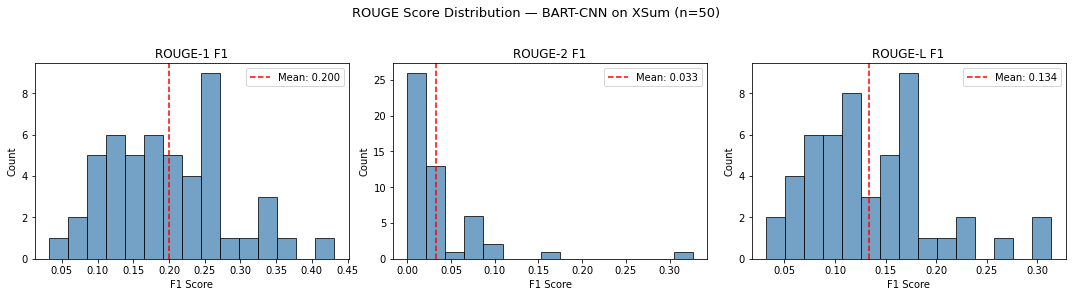

Best  ROUGE-1: 0.431  (example #14)
Worst ROUGE-1: 0.032  (example #48)


In [9]:
# Plot the F1 distribution for each metric side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))           # 3 side-by-side histogram panels

for ax, col, title in zip(
    axes,
    ["r1_f", "r2_f", "rL_f"],
    ["ROUGE-1 F1", "ROUGE-2 F1", "ROUGE-L F1"]
):
    ax.hist(df[col], bins=15, color="steelblue",
            edgecolor="black", alpha=0.75)                 # blue bars, black outlines
    ax.axvline(
        df[col].mean(),
        color="red", linestyle="--",
        label=f"Mean: {df[col].mean():.3f}"               # red dashed line = mean
    )
    ax.set_title(title)
    ax.set_xlabel("F1 Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle(
    "ROUGE Score Distribution — BART-CNN on XSum (n=50)",
    y=1.02, fontsize=13
)
plt.tight_layout()
plt.savefig("rouge_distributions.png", bbox_inches="tight")  # save for slides/report
plt.show()

# Identify the best and worst performing examples for discussion
best_idx  = df["r1_f"].idxmax()                          # index of highest ROUGE-1 F1
worst_idx = df["r1_f"].idxmin()                          # index of lowest  ROUGE-1 F1
print(f"Best  ROUGE-1: {df.loc[best_idx,  'r1_f']:.3f}  (example #{df.loc[best_idx,  'id']})") 
print(f"Worst ROUGE-1: {df.loc[worst_idx, 'r1_f']:.3f}  (example #{df.loc[worst_idx, 'id']})") 

## Section 8 — Faithfulness Check

In [10]:
# Surface the highest-scoring example for a manual faithfulness inspection
top = df.loc[df["r1_f"].idxmax()]                        # row with highest ROUGE-1 F1

print(f"Example #{int(top['id'])}  |  ROUGE-1 F1 = {top['r1_f']:.3f}")
print("=" * 70)

print("\n--- SOURCE ARTICLE (first 600 chars) ---")
print(top["article"][:600])                              # enough context for a manual check

print("\n--- REFERENCE SUMMARY (XSum gold) ---")
print(top["reference"])                                  # what a human editor wrote

print("\n--- GENERATED SUMMARY (BART-CNN) ---")
print(top["generated"])                                  # what the model produced

print("""
--- Manual Faithfulness Check Protocol ---
1. Read the generated summary.
2. For each factual claim, highlight it in the article text.
3. Any claim with no highlight = potential hallucination.
4. Record: entity errors, relation errors, out-of-article facts.

Key lesson: ROUGE only measures n-gram overlap with the reference.
It cannot detect facts that are fluent but absent from the source.
A summary can score 0.40+ ROUGE-1 and still hallucinate.
""")

Example #14  |  ROUGE-1 F1 = 0.431

--- SOURCE ARTICLE (first 600 chars) ---
Taylor, 25, joined County in May from Macclesfield, but has yet to start in the league.
The move has left Newport with only one goalkeeper in Joe Day, but manager John Sheridan is confident he will quickly fill the vacancy.
"Rhys is too good a goalkeeper to be kept on the bench and not playing football," said Sheridan.
"Financially it might enable me to bring someone else in, to try and fill in a different area."
On Saturday Newport host fourth-placed Northampton Town hoping to win their third game in a row for the first time since last December, 2014.
The Exiles are also seeking their first h

--- REFERENCE SUMMARY (XSum gold) ---
Newport County goalkeeper Rhys Taylor has joined Wrexham on loan until January.

--- GENERATED SUMMARY (BART-CNN) ---
Rhys Taylor has joined Wrexham on loan until the end of the season. Newport County are currently without a second goalkeeper. John Sheridan is confident he will have

In [11]:
# Side-by-side length comparison — illustrates the style mismatch
df["ref_len"] = df["reference"].apply(lambda x: len(x.split()))   # reference word count
df["gen_len"] = df["generated"].apply(lambda x: len(x.split()))   # generated word count

print("=== Word Count Comparison ===")
print(f"Reference avg length : {df['ref_len'].mean():.1f} words")  # XSum ~20–25 words
print(f"Generated avg length : {df['gen_len'].mean():.1f} words")  # BART-CNN ~60–80 words
print()
print("BART-CNN was trained on CNN/DM where references are paragraph-length.")
print("It has no incentive to compress to XSum's single-sentence style.")
print("This length ratio directly suppresses ROUGE recall.")

=== Word Count Comparison ===
Reference avg length : 20.6 words
Generated avg length : 36.8 words

BART-CNN was trained on CNN/DM where references are paragraph-length.
It has no incentive to compress to XSum's single-sentence style.
This length ratio directly suppresses ROUGE recall.


## Section 9 — Pivot to the Integration

In [12]:
# Summary comparison table — what you will replicate on your own corpus
summary_table = pd.DataFrame({
    "Corpus"           : ["CNN/DailyMail (BART-CNN native)", "XSum (SI demo — this notebook)", "Your corpus (M7 assignment)"],
    "Reference style"  : ["Paragraph (3–5 sentences)",        "Single abstractive sentence",    "Paragraph — tech/entertainment news"],
    "ROUGE-1 F1 (est.)": ["~0.44",                            "~0.18–0.25",                    "Run and report"],
    "Key failure mode" : ["Extractive drift",                  "Length mismatch + abstraction gap", "TBD — your analysis"]
})

print(summary_table.to_string(index=False))              # print without row index

print("""
=== Your Integrated Report (Module 7 Assignment) ===

You will run the SAME harness on your assigned corpus and report:
  - ROUGE-1, ROUGE-2, ROUGE-L mean F1
  - Per-summary distribution
  - At least one faithfulness failure ROUGE did not catch

Then synthesise all three M7 measurements:
  [M7A] BERTScore      — semantic similarity (embedding space)
  [M7B] Readability    — Flesch / Gunning Fog on generated text
  [M7B] ROUGE          — lexical overlap with reference (this lab)

Decision matrix question:
  'Given these three measurements, would you deploy this model for
   your domain? What trade-offs would you document for stakeholders?'

The SI does NOT write this report — that integration is YOUR work.
""")

                         Corpus                     Reference style ROUGE-1 F1 (est.)                  Key failure mode
CNN/DailyMail (BART-CNN native)           Paragraph (3–5 sentences)             ~0.44                  Extractive drift
 XSum (SI demo — this notebook)         Single abstractive sentence        ~0.18–0.25 Length mismatch + abstraction gap
    Your corpus (M7 assignment) Paragraph — tech/entertainment news    Run and report               TBD — your analysis

=== Your Integrated Report (Module 7 Assignment) ===

You will run the SAME harness on your assigned corpus and report:
  - ROUGE-1, ROUGE-2, ROUGE-L mean F1
  - Per-summary distribution
  - At least one faithfulness failure ROUGE did not catch

Then synthesise all three M7 measurements:
  [M7A] BERTScore      — semantic similarity (embedding space)
  [M7B] Readability    — Flesch / Gunning Fog on generated text
  [M7B] ROUGE          — lexical overlap with reference (this lab)

Decision matrix question:
  'Given 